# Neural Network from Scratch

## Load Libraries

In [4]:
import numpy as np # for implementing Neural Network
import pandas as pd # for data loading
import matplotlib.pyplot as plt # for visualisation
import seaborn as sns # for visualization

from sklearn.preprocessing import StandardScaler # for data scaling
from sklearn.model_selection import train_test_split # for train/test split
import tensorflow as tf # for camparing

## Get Data

In [5]:
data = pd.read_csv("car_purchasing.csv",encoding='ISO-8859-1')
data.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


## Feature Selecetion & Encoding + Normaliization

Feature selecting

In [ ]:
# customer name, customer e-mail and country columns can be dropped
selected_features = data.describe().columns # getting only numerical features
                                               # last feature is our target
print(selected_features.values)

['gender' 'age' 'annual Salary' 'credit card debt' 'net worth'
 'car purchase amount']


Storing data with only selected features

In [ ]:
selected_features_data = data[selected_features] # data only with selected features
selected_features_data.head()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


Data Analysis

In [ ]:
selected_features_data.describe()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


Data looks clean, let's check for missing values and duplicates

In [ ]:
selected_features_data.isna().sum()

,0
gender,0
age,0
annual Salary,0
credit card debt,0
net worth,0
car purchase amount,0


In [ ]:
selected_features_data.duplicated().sum()

np.int64(0)

Data is clean.

We have 1 categorical feature (`gender`) but it's already encoded into binary format which works with our future model.

Next step is to scale our data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# scaler = StandardScaler() # init our scaler
scaler = MinMaxScaler()
selected_features_data_scaled = scaler.fit_transform(selected_features_data) # fit scaler and transform our data
print(selected_features_data_scaled[:5])

[[0.         0.4370344  0.53515116 0.57836085 0.22342985 0.37072477]
 [0.         0.41741247 0.58308616 0.476028   0.52140195 0.50866938]
 [1.         0.46305795 0.42248189 0.55579674 0.63108896 0.47782689]
 [1.         0.76542739 0.74212547 0.71990778 0.53938679 0.82285018]
 [1.         0.74627499 0.49661439 0.26425689 0.55133068 0.66078116]]


Assigning X and y variables

In [ ]:
X = selected_features_data_scaled[:, :5]
y = selected_features_data_scaled[:, 5]
X.shape, y.shape

((500, 5), (500,))

## Visualize Data

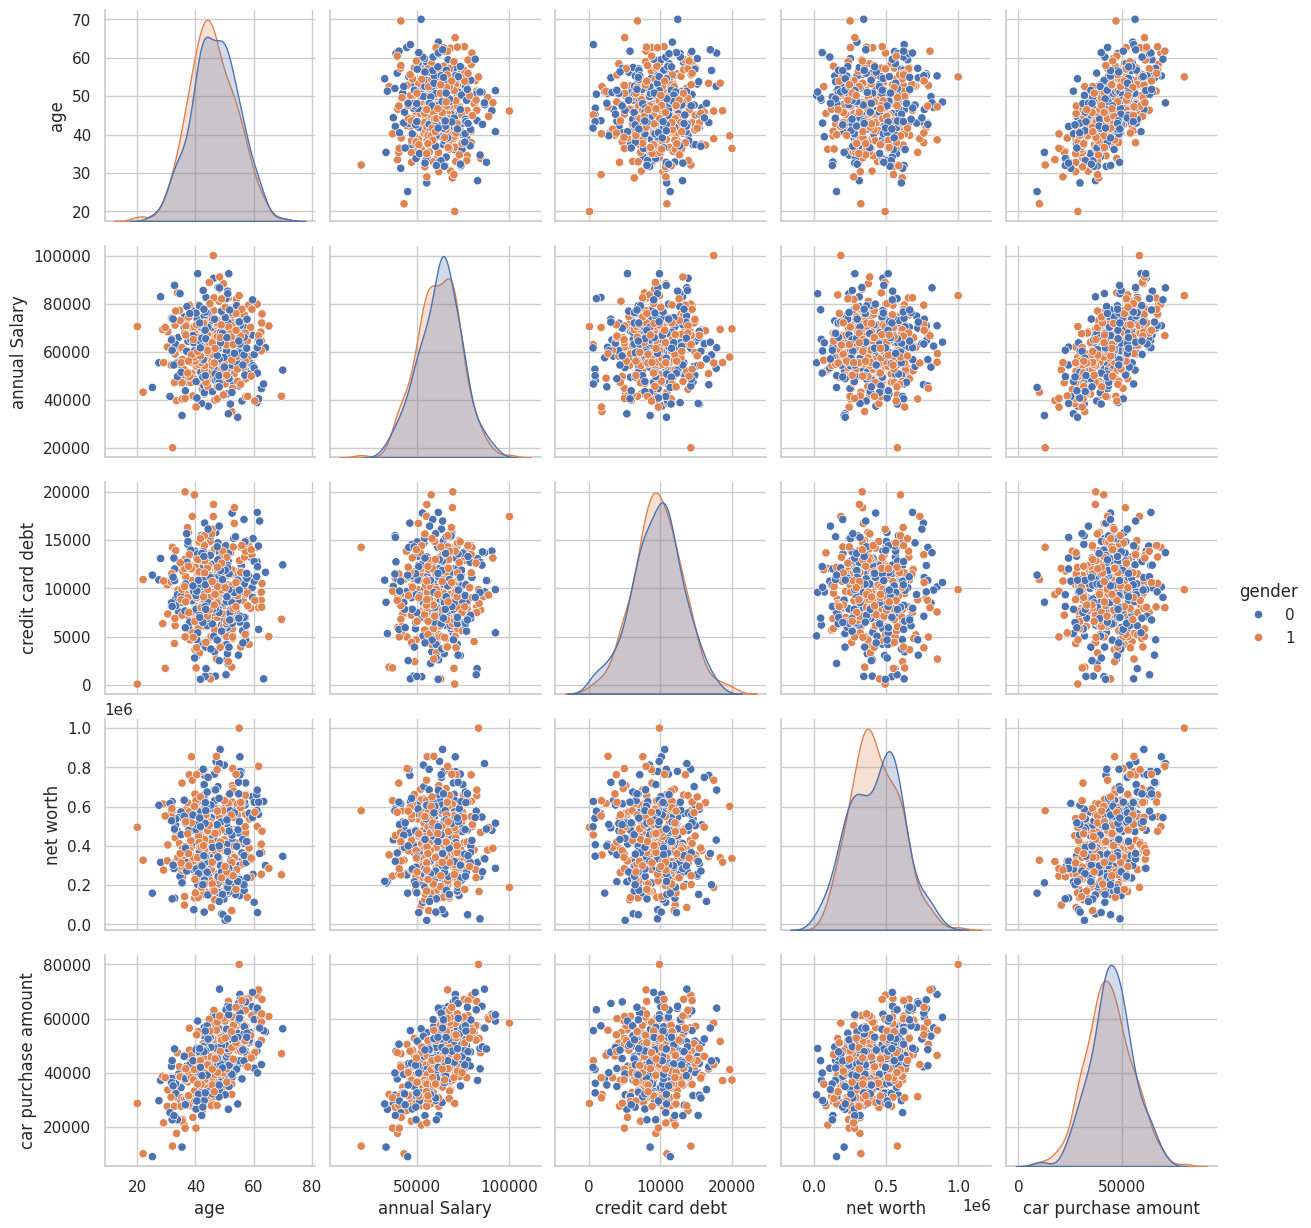

In [ ]:
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook"
)

sns.pairplot(selected_features_data, hue='gender')
plt.show()

We can see that features (`age`, `annual Salary`, `net worth`) have visible correlation with our target variable (`car purchase amount`)

We could achive good predictions with this data

## Custom Neural Network Implementation

In [ ]:
class Scalar():

  def __init__(self, data: float, _children=(), label=''):
    """
    Scalar object that stores single value
    Parameters:
      data (float): any number in float format
      label (str): optional, name for the object
    """
    self.data = data
    self.grad = 0.0 # gradient value; computed when back propagation is called
    self._backward = lambda: None # function to perform back propagation, actual function assigns during the computations
    self._prev = set(_children) # set of previous operations (instances of Scalar)
    self.label = label # label for Scalar if present

  def __get_scalar__(self, other: float):
    """
    Function to make other be instance of Scalar
    Parameters:
      other (float): any float value
    Returns:
      Scalar: creates new instance of scalar by passing {other} value
              or returns other if it is already instance of Scalar
    """
    return other if isinstance(other, Scalar) else Scalar(other)

  def __add__(self, other: float):
    """
    Performs addition operation for 2 instances of Scalar
    Computes backward function for the current operation
    Parameters:
      other (float | Scalar): number to be added to
    Returns:
      Scalar: new Scalar instance that contains result of the addition
    """
    other = self.__get_scalar__(other) # check if other is Scalar
    out = Scalar(self.data + other.data, (self, other)) # computes the result of addition and creates new instance of Scalar

    def backward(): # create function that performs back propagation
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = backward # assigns created function to the result Scalar object for fututre chain
    return out # returns result of computation in form of Scalar

  def __mul__(self, other: float):
    """
    Performs multiplication operation for 2 instances of Scalar
    Computes backward function for the current operation
    Parameters:
      other (float | Scalar): number to be multiplied
    Returns:
      Scalar: new Scalar instance that contains result of the multiplication
    """
    other = self.__get_scalar__(other)
    out = Scalar(self.data * other.data, (self, other))

    def backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = backward
    return out

  def __pow__(self, other: float | int):
    """
    Performs raising to power - {other} for the self object (self^other)
    Computes backward function for the current operation
    Parameters:
      other (float | int): number to be raised to
    Returns:
      Scalar: new Scalar instance that contains result of raising to power
    """
    assert isinstance(other, (int, float)) # check for number
    out = Scalar(self.data**other, (self, ))

    def backward():
      self.grad += other * (self.data**(other-1.0)) * out.grad # derivative for power rule
    out._backward = backward

    return out

  def tanh(self):
    """
    Performs tanh activation for self object
    Computes backward function for the current operation
    Returns:
      Scalar: new Scalar instance that contains result of the computation
    """
    x = self.data
    t = (np.exp(2.0*x) - 1.0)/(np.exp(2.0*x) + 1.0) # formula for computing tanh
    out = Scalar(t, (self, ))

    def backward():
      self.grad += (1.0 - t**2.0) * out.grad # derivative of tanh function formula
    out._backward = backward

    return out

  def relu(self):
    """
    Performs relu activation for self object
    Computes backward function for the current operation
    Returns:
      Scalar: new Scalar instance that contains result of the computation
    """
    x = self.data
    res = x if x > 0 else 0.0 # formula for computing relu
    out = Scalar(res, (self, ))

    def backward():
      self.grad += (1.0 if x > 0 else 0.0) * out.grad # derivative formula for relu
    out._backward = backward

    return out

  def softplus(self):
    """
    Performs softplus activation for self object
    Computes backward function of the current operation
    Returns:
      Scalar: new Scalar object instance that contains result of computation
    """
    x = self.data
    out_data = np.log1p(np.exp(x))  # stable-ish for moderate x
    out = Scalar(out_data, (self,))

    def _backward():
        sig = 1.0 / (1.0 + np.exp(-x)) # derivative: sigmoid(x) = 1 / (1 + exp(-x))
        self.grad += sig * out.grad

    out._backward = _backward
    return out

  def backward(self):
    """
    Performs backward computing to get gradients with respect of current self
    Builds topological order of instances: (gradient chain)
    calls _backward function for each node to compute gradients
    """
    topo = [] # a list to store all nodes in the rigth order
    seen = set() # a set to check whether node has been checked already

    def build_topo(v: Scalar) -> None:
      """
      Function to build topological order for Scalars
      The last instance would be self
      Creates a chain of instances for gradient computation
      Parameters:
        v (Scalar): Scalar object which is the object whose derivative would be computed with respect of each child
      """
      if v not in seen: # if Scalar hasn't been checked yet, then recursivly check its children
        seen.add(v) # add current Scalar to seen to prevent repetition
        for child in v._prev: # fro each child of current node recursivly walk through
          build_topo(child)
        topo.append(v) # append current node to topological list

    build_topo(self) # calling function on current node
    self.grad = 1.0 # setting grad to 1, derivative of self with respect to self is 1
    for node in reversed(topo): # reversed, because the last node has to be first for back propogation
      node._backward()

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1.0

  def __neg__(self):
    return self * -1.0

  def __sub__(self, other):
    return self + (-other)

  def __repr__(self):
    return f"Scalar(data={self.data})"


class Neuron():
  def __init__(self, nin):
    """
    Initialise Neuron
    Parameters:
      nin: (int): number of scalar values in this neuron
    """
    self.nin = nin
    self.w = np.array([Scalar(value[0] * np.sqrt(2.0 / nin)) for value in np.random.randn(nin).reshape(-1, 1)]) # randomly generated weights
    self.b = Scalar(0.0) # bias is set to 0

  def f(self, X: np.array) -> np.array:
    """
    Main function for predicting: y = wx + b
    Parameters:
      X (np.array): train data, excluding y
    Returns:
      np.array: Predictions for train data
    """
    return X.dot(self.w) + self.b

  def __call__(self, X: np.array, activation: str = 'linear') -> np.array:
    """
    Performs computing of predictions and activation for this neuron
    Parameters:
      X (np.array): train data
      activation (str): activation function (linear by default)
    Returns:
      np.array: predictions with activations
    """
    result = self.f(X) # basic matrix multiplication, result is (batch_size,) array of Scalars
    if activation == 'linear':
      activated_result = np.array([g for g in result]) # activation function for each scalar
    elif activation == 'relu':
      activated_result = np.array([g.relu() for g in result]) # activation function for each scalar
    elif activation == 'tanh':
      activated_result = np.array([g.tanh() for g in result]) # activation function for each scalar
    elif activation == 'softplus':
      activated_result = np.array([g.softplus() for g in result]) # activation function for each scalar
    return activated_result # Returns (batch_size,) array of Scalars

  def parameters(self) -> np.array:
    """
    Function to get all parameters of the neuron, weights and bias
    Returns:
      np.array: combination of all parameters
    """
    return np.concatenate([self.w, np.array([self.b])], axis=0)

  def __repr__(self):
    return f"Neuron(nin={self.nin})"


class Layer():
  def __init__(self, n_in: int, n_out:int, name='dense_layer', activation='linear'):
    """
    Initialise layer of the model
    Paramaters:
      n_in (int): number of neurons in this layer
      n_out (int): number of neurons for output
      name (str): name for this layer
      activation (str): activation function for each neuron, default - linear
    """
    self.n_in = n_in
    self.n_out = n_out
    self.neurons = [Neuron(self.n_in) for _ in range(self.n_out)] # generate number of neurons in the layer
    self.activation = activation
    self.name = name # name of the layer

  def __call__(self, X: np.array) -> np.array:
    """
    Calls each neuron with X
    Each n(X) returns a (batch_size,) array of Scalar objects.
    Parameters:
      X (np.array): train data
    Returns:
      np.array: array of the predictions from each neuron
    """
    outs = [n(X, activation=self.activation) for n in self.neurons] # outs is a list of n_out (batch_size,) arrays
    return np.column_stack(outs) # Stacks into a (batch_size, n_out) array of Scalar objects

  def parameters(self) -> np.array:
    """
    Function to get all parameters of the layer, weights and bias
    Gets parameters from each Neuron and returns them as np.array
    Returns:
      np.array: combination of all parameters
    """
    return np.array([p for neuron in self.neurons for p in neuron.parameters()]) # return all parameters of each neuron

  def __repr__(self):
    return f"Layer(n_in={self.n_in}, n_out={self.n_out}, activation={self.activation}, name={self.name})"

class NeuralNetwork:
  def __init__(self, sequential: list):
    """
    Initialise Neural Network
    Parameters:
      sequential (list): structure of the neural network, example:
                        [
                          Layer(n_in=10, n_out=16, activation='relu'),
                          Layer(n_in=16, n_out=1, activation='linear')
                        ]
      n_in: how many neurons in the layer; for first layer n_in should number of features in the data
      n_out: how many neurons this layer should produce
      activation: 'linear' is default, 'tanh', 'relu', 'softplus' are implemented.
    """
    self.epochs = 10
    self.sequential = sequential # Layers structure
    self.loss_history = []

  def zero_grad(self):
    """
    Sets gradient of all params to 0
    """
    for p in self.parameters():
      p.grad = 0.0

  def __call__(self, X) -> np.array:
    """
    Performs a forward pass through the network.
    Parameters:
      X (np.array): train data
    Returns:
      np.array: current predictions
    """
    # Assumes layers are already specified
    if not self.sequential:
      raise RuntimeError("NeuralNetwork layers have not been built")

    current_input = X
    for layer in self.sequential:
      current_input = layer(current_input)
    return current_input # Final output of the network, (batch_size, 1) array of Scalars

  def parameters(self) -> np.array:
    """
    Function to get all parameters of the Neural Network, weights and bias
    Returns:
      np.array: combination of all parameters
    """
    params = []
    for layer in self.sequential:
        params.extend(layer.parameters())
    return np.array(params)

  def fit(
      self,
      X: np.array, y:np.array,
      learning_rate:float=0.01,
      epochs:int=10,
      batch_size:int=32
      ) -> np.array:
    """
    Main function to train neural network on the data provided
    Parameters:
      X (np.array): train data
      y (np.array): true labels
      learning_rate (float): step size for gradient descent
      epochs (int): number of iterations for training
      batch_size (int): number of records per batch
    Returns:
      np.array: final predictions
    """
    X_copy = np.copy(X) # copy data to prevent changes to original
    self.epochs = epochs # set epochs

    N = X_copy.shape[0] # number of samples in our data
    # convert true labels to scalars and store into 1D np.array
    y_target_scalars = np.array([Scalar(float(val)) for val in y]).reshape(-1, 1)

    for epoch in range(epochs):

      idx = np.random.permutation(N) # randomly shuffle indexes of training data, N is a length of our data
      X_shuf = X[idx]
      y_shuf = y_target_scalars[idx]

      epoch_loss = 0.0 # loss per this epoch
      num_batches = 0 # number of batches that have been already iterated

      for start in range(0, N, batch_size):
        # start is the index that corresponds to the beginning of tthe current batch
        # end is the index that corresponds to the last record of this batch
        end = start + batch_size
        X_batch = X_shuf[start:end]
        y_batch = y_shuf[start:end]
        B = len(X_batch) # for computing loss for current batch

        y_pred = self(X_batch) # performs forward propagation

        diff = y_batch - y_pred # differnece between predictions and true labels
        squared = [d**2 for d in diff.flatten()] # square differense for MSE
        loss = sum(squared, Scalar(0.0)) * (1.0 / B) # sum all squares and divide by len of the batch

        self.zero_grad() # set grads to 0
        loss.backward() # performs back propagation on our loss

        # performs gradient descent algorithm
        for p in self.parameters():
            p.data += -learning_rate * p.grad # update values to get minimum loss

        epoch_loss += loss.data
        num_batches += 1

      self.loss_history.append(epoch_loss) # add loss per each epoch to the list
      print(f"Epoch {epoch+1}/{epochs} --- loss: {(epoch_loss / num_batches):2f}")

  def predict(self, X_test: np.array) -> np.array:
    """
    Predicts result based on data fitted, number of features should be the same as for training
    Parameters:
      X_test (np.array): array of data for predictions, X_test.shape[1] should == X_train.shape[1]
    Returns:
      np.array: 1D array of predicitons
    """
    y_pred = self(X_test) # getting predictions
    y_pred = np.array([prediction.data for prediction in y_pred.flatten()]) # flattening array to make it 1D and
                                                                            # extracting only data from Scalar
    return y_pred

  def __repr__(self):
    layers_repr = "\n".join(str(layer) for layer in self.sequential)
    return f"NeuralNetwork(sequential=[\n{layers_repr}\n])"

## Train/Test Data Split

In [ ]:
X_train, y_train = X[:400], y[:400]
X_test, y_test = X[400:], y[400:]

## Fitting Custom Neural Network

In [ ]:
np.random.seed(42)
sequential = [
    Layer(n_in=X_train.shape[1], n_out=16, activation='tanh', name='Hidden_Dense_1'),
    Layer(n_in=16, n_out=16, activation='relu', name='Hidden_Dense_2'),
    Layer(n_in=16, n_out=32, activation='relu', name='Hidden_Dense_3'),
    Layer(n_in=32, n_out=8, activation='softplus', name='Hidden_Dense_4'),
    Layer(n_in=8, n_out=1, activation='linear', name='Output_layer'),
]

custom_nn = NeuralNetwork(sequential=sequential)
custom_nn.fit(X_train, y_train, epochs=10, learning_rate=0.001)

Epoch 1/10 --- loss: 0.021056
Epoch 2/10 --- loss: 0.021245
Epoch 3/10 --- loss: 0.020560
Epoch 4/10 --- loss: 0.020743
Epoch 5/10 --- loss: 0.020358
Epoch 6/10 --- loss: 0.021041
Epoch 7/10 --- loss: 0.020222
Epoch 8/10 --- loss: 0.020939
Epoch 9/10 --- loss: 0.019876
Epoch 10/10 --- loss: 0.020204


In [ ]:
print(custom_nn)

NeuralNetwork(sequential=[
Layer(n_in=5, n_out=16, activation=tanh, name=Hidden_Dense_1)
Layer(n_in=16, n_out=16, activation=relu, name=Hidden_Dense_2)
Layer(n_in=16, n_out=32, activation=relu, name=Hidden_Dense_3)
Layer(n_in=32, n_out=8, activation=softplus, name=Hidden_Dense_4)
Layer(n_in=8, n_out=1, activation=linear, name=Output_layer)
])


### Reusable Functions

In [ ]:
# function to inverse transform scalled data and combine it with predicted values
def inverse_data_combine_predicitons(X, y_true, y_pred, feature_names):
  combined_orig = np.concatenate([X, y_true.reshape(-1, 1)], axis=1)
  inverse_transformed_orig = scaler.inverse_transform(combined_orig)

  combined_predicted = np.concatenate([X, y_pred.reshape(-1, 1)], axis=1)
  inverse_transformed_pred = scaler.inverse_transform(combined_predicted)

  df = pd.DataFrame(inverse_transformed_orig, columns=feature_names)
  df['Predicted'] = inverse_transformed_pred[:, X_train.shape[1]]
  return df

# function to plot the actual data points and our predictions
def plot_predictions(x_axis, y_true, y_pred, title, x_label, y_label):
  plt.figure(figsize=(8, 8))
  plt.scatter(x_axis, y_true, label='True', c='b')
  plt.scatter(x_axis, y_pred, label='Pred', c='r')
  plt.title(title)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.legend()
  plt.show()

## Train tf.Keras Model with the Same Parameters

In [ ]:
np.random.seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, input_shape=(5,), activation='tanh'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(8, activation='softplus'),
    tf.keras.layers.Dense(1, activation='linear'),
])

model.summary()

model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=['mse']
)

model.fit(X_train, y_train, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3520 - mse: 0.3520  
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2474 - mse: 0.2474 
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1709 - mse: 0.1709 
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1124 - mse: 0.1124 
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0858 - mse: 0.0858 
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0609 - mse: 0.0609 
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0475 - mse: 0.0475 
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0383 - mse: 0.0383 
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0344 - mse: 0.0344 
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0257 - mse: 0.0257 


## Getting & Comparing Predicitons

In [ ]:
y_pred_custom = custom_nn.predict(X_test)

In [ ]:
y_pred_keras = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [ ]:
inversed_results_custom = inverse_data_combine_predicitons(
    X=X_test,
    y_true=y_test,
    y_pred=y_pred_custom,
    feature_names=selected_features
) # transform our data back to original and add Custom Neural Network's predictions

inversed_results_keras = inverse_data_combine_predicitons(
    X=X_test,
    y_true=y_test,
    y_pred=y_pred_keras,
    feature_names=selected_features
) # transform our data back to original and add Keras' predictions

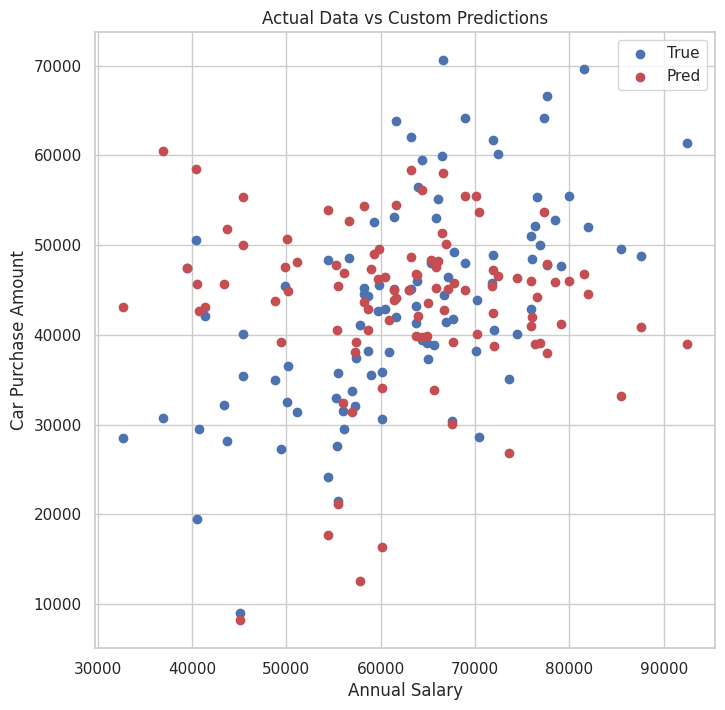

In [ ]:
# for Custom Preds
plot_predictions(
    x_axis=inversed_results_custom['annual Salary'],
    y_true=inversed_results_custom['car purchase amount'],
    y_pred=inversed_results_custom['Predicted'],
    title='Actual Data vs Custom Predictions',
    x_label='Annual Salary',
    y_label='Car Purchase Amount')

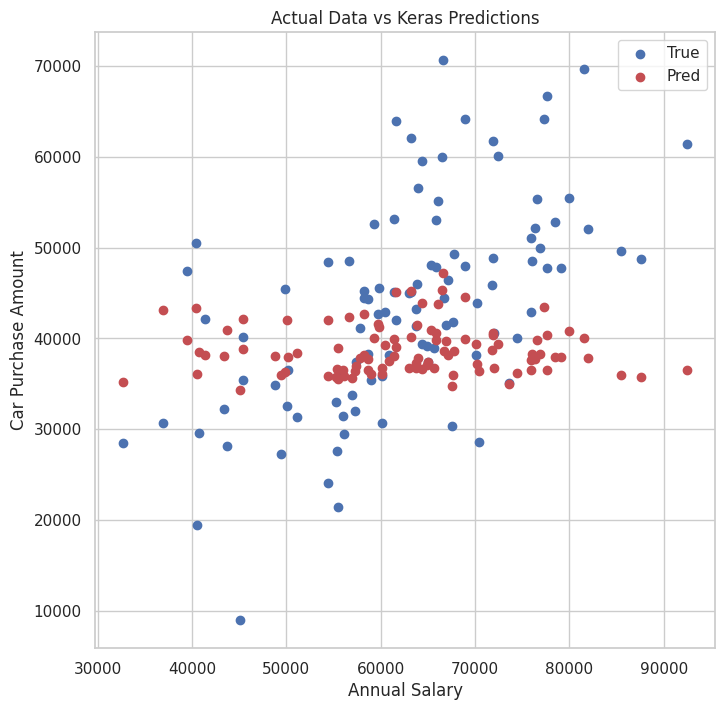

In [ ]:
# for Keras Preds
plot_predictions(
  x_axis=inversed_results_keras['annual Salary'],
  y_true=inversed_results_keras['car purchase amount'],
  y_pred=inversed_results_keras['Predicted'],
  title='Actual Data vs Keras Predictions',
  x_label='Annual Salary',
  y_label='Car Purchase Amount'
)

__Loss curve of our Custom Model__

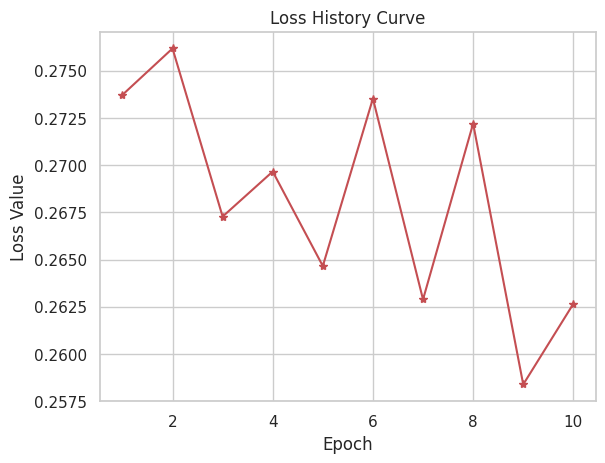

In [ ]:
def plot_loss_history(epochs, loss_history):
  plt.plot(epochs, custom_nn.loss_history, '*-r')
  plt.title(f"Loss History Curve")
  plt.xlabel('Epoch')
  plt.ylabel('Loss Value')
  plt.show()

epochs = np.arange(1, 11)
plot_loss_history(epochs, custom_nn.loss_history)

__Conclusion__:

Custom Neural Network from Scratch is fully functional. Using the dataset I found on `Kaggle` (link: https://www.kaggle.com/datasets/yashpaloswal/ann-car-sales-price-prediction?select=car_purchasing.csv
), I trained the Neural Network and compared its predictions with an official `tensorflow.keras` model using the same parameters.

Final loss for the custom model: __0.020__; final loss for the Keras model: __0.0257__. The numbers are very close to each other, which means the custom model can actually be used for regression problems (at least for this dataset 😉).

The visualised predictions of the custom model are more expanded, while the Keras predictions look more linear and distributed toward the center. This suggests that the custom model might be more _vulnerable_ to high variance.

This is only the __base__; future improvements and adjustments can be easily implemented.

__Summary:__

I implemented a `Neural Network` from _Scratch_ (using __NumPy__). When I started implementing a _Scalar_ class, I realised that __NumPy__ is not actually needed for the main logic. The simple __math__ module would be enough for calculations; however, __NumPy__ still helped me with _shape_ issues, and it is more efficient than using Python's default lists.

While implementing the _backpropagation_ logic, I actually understood how it works - it is a very simple concept (thanks to debugging). At this point of development, this `Neural Network` can solve only _regression_ problems. I used only a basic metric (__MSE__), the most popular activation functions (__linear__, __ReLU__, softplus__, and __tanh__), and simple __gradient descent__.

However, using this _baseline_, I can move on to implementing something larger, with many parameters and tunings, adding multiple metrics, more layers, and callbacks. This has been a great experience for me because I truly understand every line of code in this notebook. This makes me passionate about future projects.